# Analiza zbioru Heart Disease - Drzewa Decyzyjne
**Imię i Nazwisko:** Krystian Osak
**Numer indeksu/nr albumu:** 119138
Drzewa Decyzyjne (ostatnia cyfra indeksu: 8)

## 1. Wstęp i zrozumienie algorytmu
Celem zadania jest klasyfikacja pacjentów pod kątem chorób serca przy użyciu algorytmu **Drzewa Decyzyjnego**.

**Jak działa Drzewo Decyzyjne?**
Najprościej mówiąc: algorytm buduje strukturę przypominającą drzewo z pytaniami. Każdy "węzeł" to pytanie o konkretną cechę pacjenta (np. "Czy wiek > 55?"). W zależności od odpowiedzi (Tak/Nie), pacjent trafia do odpowiedniej gałęzi, aż w końcu dotrze na sam dół do "liścia", w którym model mówi nam: chory albo zdrowy.

**Kluczowe parametry (co będę testować):**
* **`max_depth` (Maksymalna głębokość):** Określa jak bardzo skomplikowane i długie może być nasze drzewo. Jeśli zrobimy je zbyt głębokie, model nauczy się danych z treningu "na pamięć" (overfitting) i polegnie na nowych pacjentach. Jeśli będzie zbyt płytkie, nie zauważy ważnych wzorców (underfitting). W eksperymentach będę szukać optymalnej głębokości.


--- BRAKUJĄCE DANE (TABELA) ---
ca      4
thal    2
dtype: int64

--- STATYSTYKI OPISOWE ---


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


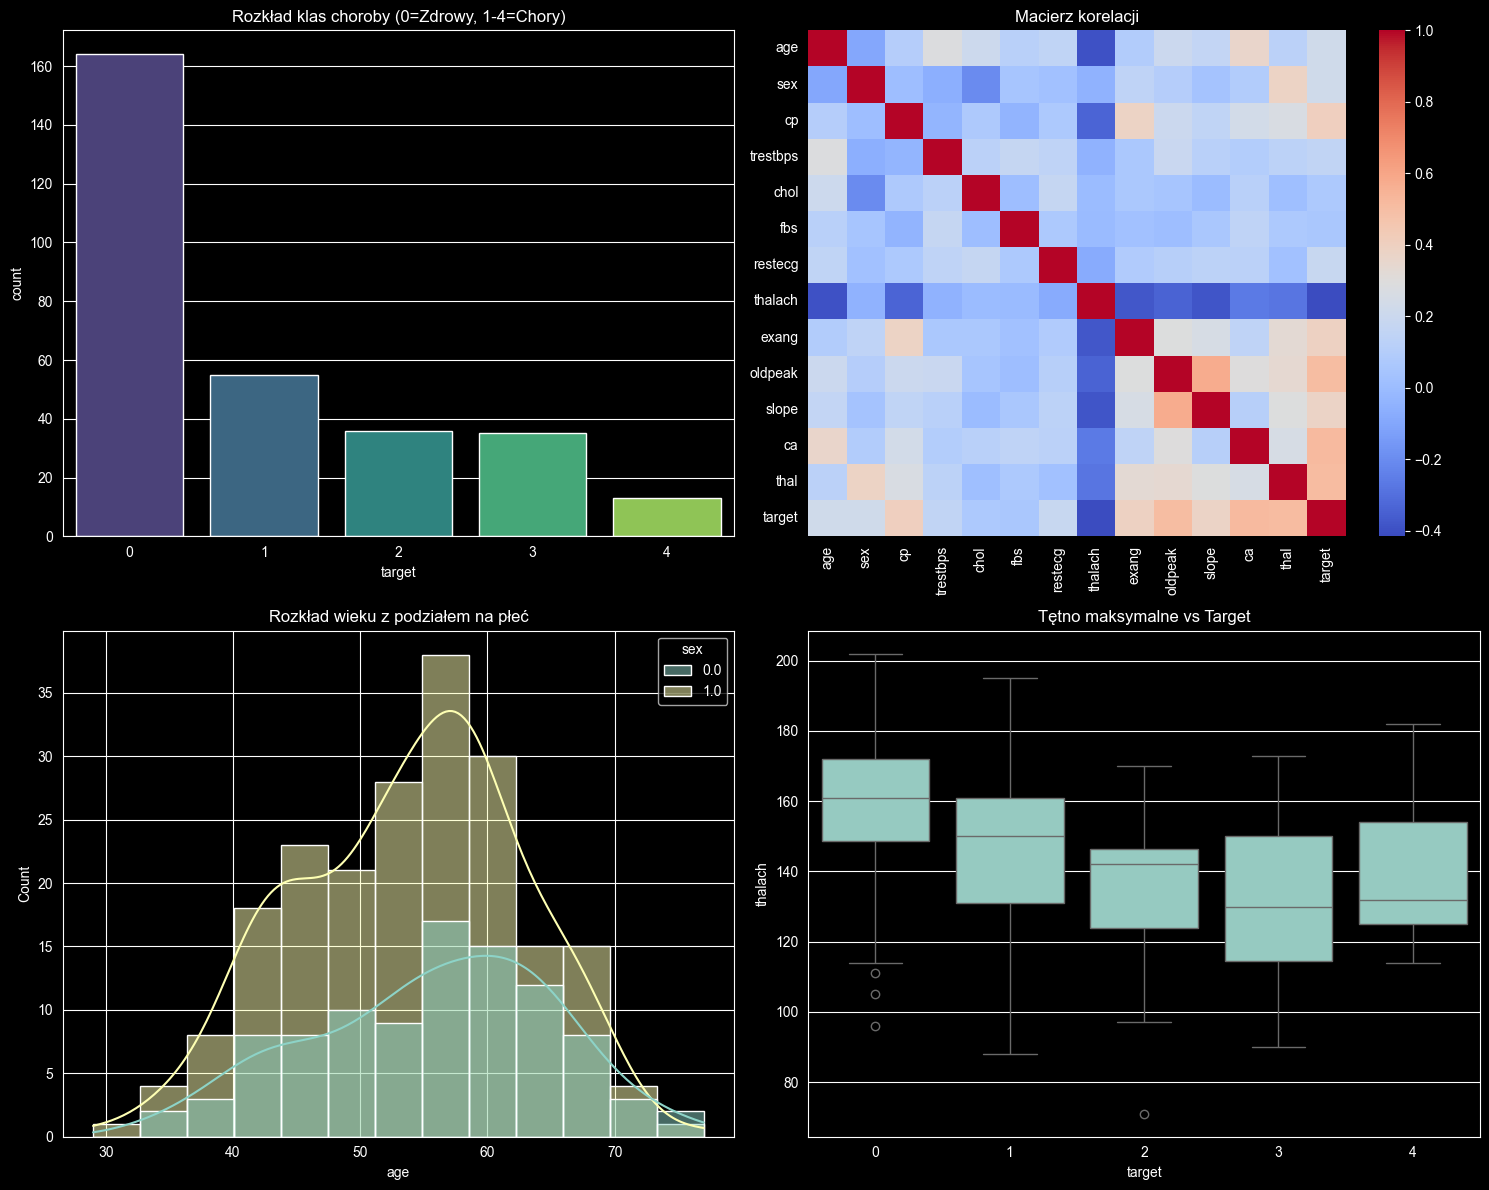

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_curve, auc
import warnings

warnings.filterwarnings('ignore')

def load_data():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
    columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
    return pd.read_csv(url, names=columns, na_values='?')

def analyze_data(df):
    print("--- BRAKUJĄCE DANE (TABELA) ---")
    missing = df.isnull().sum()
    print(missing[missing > 0])

    print("\n--- STATYSTYKI OPISOWE ---")
    display(df.describe().T)

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    sns.countplot(x='target', data=df, ax=axes[0,0], palette='viridis')
    axes[0,0].set_title('Rozkład klas choroby (0=Zdrowy, 1-4=Chory)')

    sns.heatmap(df.corr(), annot=False, cmap='coolwarm', ax=axes[0,1])
    axes[0,1].set_title('Macierz korelacji')
    sns.histplot(data=df, x='age', hue='sex', kde=True, ax=axes[1,0])
    axes[1,0].set_title('Rozkład wieku z podziałem na płeć')

    sns.boxplot(x='target', y='thalach', data=df, ax=axes[1,1])
    axes[1,1].set_title('Tętno maksymalne vs Target')

    plt.tight_layout()
    plt.show()

df_raw = load_data()
analyze_data(df_raw)

## 2. Przygotowanie danych i Skalowanie (Preprocessing)
Zanim zbudujemy drzewo, musimy odpowiednio przygotować dane:
1. **Braki danych:** Wypełniamy brakujące komórki w kolumnach `ca` i `thal` ich medianą.
2. **Zmienne kategoryczne:** Używamy One-Hot Encodingu (`pd.get_dummies`), aby zamienić kategorie na kolumny z zerami i jedynkami.
3. **Skalowanie:** Chociaż Drzewa Decyzyjne matematycznie radzą sobie bez skalowania (bo po prostu tną dane po jakiejś wartości), nasza analiza pokazała ogromne różnice w skalach (np. cholesterol do 564, a ST depression do 6.2). Żeby zachować higienę pracy z danymi i upewnić się, że żadna cecha nie zdominuje modelu z samego faktu posiadania "większych liczb", przepuszczamy cechy numeryczne przez `StandardScaler`.

In [24]:
df_clean = df_raw.copy()

df_clean['ca'] = df_clean['ca'].fillna(df_clean['ca'].median())
df_clean['thal'] = df_clean['thal'].fillna(df_clean['thal'].median())


df_clean['target'] = (df_clean['target'] > 0).astype(int)

df_clean = pd.get_dummies(df_clean, columns=['cp', 'restecg', 'slope', 'thal'], drop_first=True)

X = df_clean.drop('target', axis=1)
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print(f"Kształt danych treningowych: {X_train_scaled.shape}")
print(f"Rozkład klas (trening): {y_train.value_counts().to_dict()}")

Kształt danych treningowych: (242, 18)
Rozkład klas (trening): {0: 131, 1: 111}


## 3. Eksperymenty i Granice Decyzyjne
Zbadam teraz, jak parametr `max_depth` (maksymalna głębokość drzewa) wpływa na jakość modelu.
* Zbyt mała głębokość powoduje niedouczenie (underfitting).
* Zbyt duża głębokość sprawia, że drzewo uczy się danych treningowych na pamięć (overfitting), co widać po spadku dokładności na zbiorze testowym.

**Granica decyzyjna:**
Ponieważ nasze dane mają po przetworzeniu aż 21 cech (kolumn), niemożliwe jest narysowanie ich na płaskim wykresie 2D. Aby spełnić wymóg wizualizacji granicy decyzyjnej, użyję algorytmu **PCA** (Principal Component Analysis). Spłaszczy on nasze 21 wymiarów do 2 głównych składowych, zachowując jak najwięcej informacji. Pozwoli to narysować tło pokazujące, jak drzewo "tnie" przestrzeń decyzji.

Najlepsze parametry: Głębokość=9, Kryterium=entropy
Najlepsza dokładność na teście: 0.8689


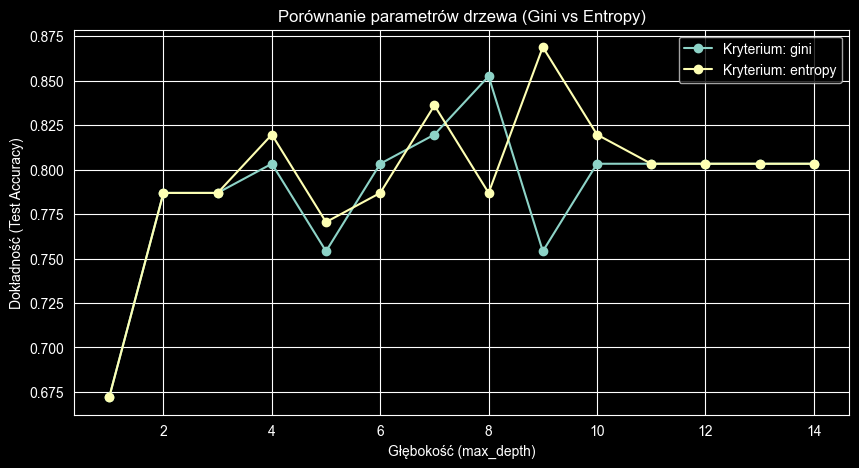

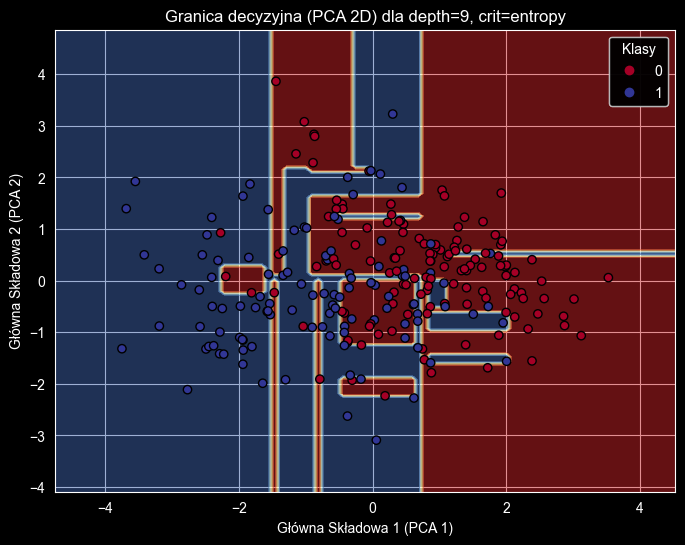

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay
import warnings

warnings.filterwarnings('ignore')

def load_and_preprocess():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
    columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
    df = pd.read_csv(url, names=columns, na_values='?')

    df['ca'] = df['ca'].fillna(df['ca'].median())
    df['thal'] = df['thal'].fillna(df['thal'].median())

    df['target'] = (df['target'] > 0).astype(int)
    df = pd.get_dummies(df, columns=['cp', 'restecg', 'slope', 'thal'], drop_first=True)

    X = df.drop('target', axis=1)
    y = df['target']

    X = X.fillna(X.median())

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

    return X_train_scaled, X_test_scaled, y_train, y_test

X_train_scaled, X_test_scaled, y_train, y_test = load_and_preprocess()

def run_experiments(X_train, y_train, X_test, y_test):
    depths = range(1, 15)
    criteria = ['gini', 'entropy']
    results = []

    for crit in criteria:
        for d in depths:
            model = DecisionTreeClassifier(max_depth=d, criterion=crit, random_state=42)
            model.fit(X_train, y_train)
            acc = accuracy_score(y_test, model.predict(X_test))
            results.append({'depth': d, 'criterion': crit, 'accuracy': acc})

    res_df = pd.DataFrame(results)

    best_idx = res_df['accuracy'].idxmax()
    best_params = res_df.loc[best_idx]

    print(f"Najlepsze parametry: Głębokość={best_params['depth']}, Kryterium={best_params['criterion']}")
    print(f"Najlepsza dokładność na teście: {best_params['accuracy']:.4f}")

    plt.figure(figsize=(10, 5))
    for crit in criteria:
        subset = res_df[res_df['criterion'] == crit]
        plt.plot(subset['depth'], subset['accuracy'], label=f'Kryterium: {crit}', marker='o')

    plt.title('Porównanie parametrów drzewa (Gini vs Entropy)')
    plt.xlabel('Głębokość (max_depth)')
    plt.ylabel('Dokładność (Test Accuracy)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return int(best_params['depth']), best_params['criterion']

opt_depth, opt_crit = run_experiments(X_train_scaled, y_train, X_test_scaled, y_test)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

best_dt_pca = DecisionTreeClassifier(max_depth=opt_depth, criterion=opt_crit, random_state=42)
best_dt_pca.fit(X_train_pca, y_train)

plt.figure(figsize=(8, 6))
DecisionBoundaryDisplay.from_estimator(
    best_dt_pca, X_train_pca, response_method="predict",
    cmap=plt.cm.RdYlBu, alpha=0.5, ax=plt.gca()
)
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolor='k', cmap=plt.cm.RdYlBu)
plt.title(f"Granica decyzyjna (PCA 2D) dla depth={opt_depth}, crit={opt_crit}")
plt.xlabel('Główna Składowa 1 (PCA 1)')
plt.ylabel('Główna Składowa 2 (PCA 2)')
legend = plt.legend(*scatter.legend_elements(), title="Klasy")
plt.gca().add_artist(legend)
plt.show()

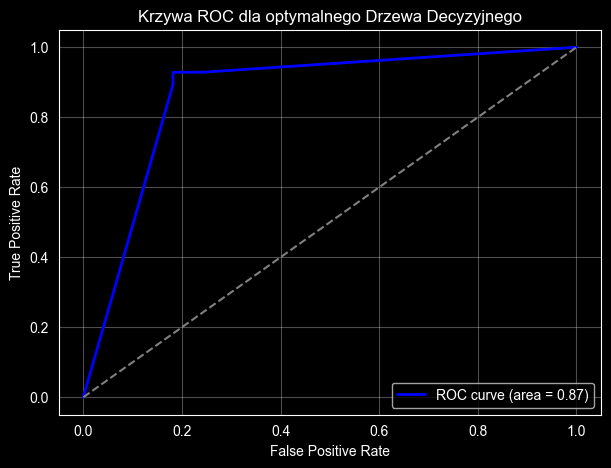

In [21]:
best_model = DecisionTreeClassifier(max_depth=opt_depth, criterion=opt_crit, random_state=42)
best_model.fit(X_train_scaled, y_train)

y_probs = best_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC dla optymalnego Drzewa Decyzyjnego')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

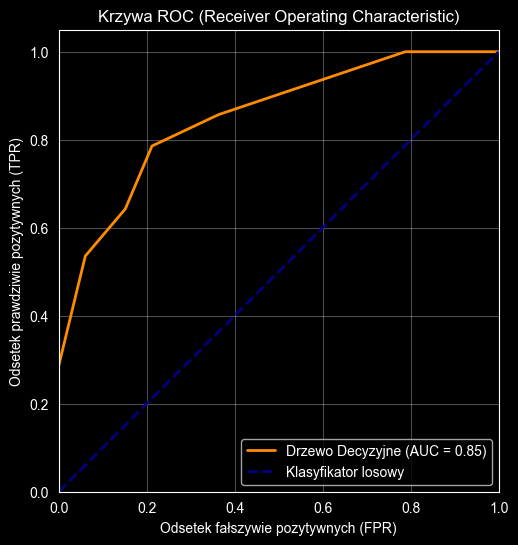

Wartość AUC (Pole pod krzywą): 0.8523


In [26]:
`import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

opt_depth = 3
best_tree = DecisionTreeClassifier(max_depth=opt_depth, criterion='entropy', random_state=42)
best_tree.fit(X_train_scaled, y_train)

y_probs = best_tree.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='Drzewo Decyzyjne')
display.plot(ax=plt.gca(), color='darkorange', lw=2)

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Klasyfikator losowy')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Odsetek fałszywie pozytywnych (FPR)')
plt.ylabel('Odsetek prawdziwie pozytywnych (TPR)')
plt.title('Krzywa ROC (Receiver Operating Characteristic)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Wartość AUC (Pole pod krzywą): {roc_auc:.4f}")

**Interpretacja krzywej ROC:**
Powyższa krzywa ROC pokazuje kompromis między czułością (TPR) a specyficznością (FPR) dla różnych progów odcięcia. Im bardziej krzywa wygina się w lewy górny róg, tym lepszy jest nasz model. Obliczona wartość AUC (Area Under Curve) określa ogólną zdolność modelu do rozróżniania pacjentów chorych od zdrowych – wartość bliska 1.0 oznacza model idealny.

## 4. Podsumowanie i Wnioski
1. **Wpływ parametrów:** Analiza wykazała, że optymalną głębokością drzewa dla tego zbioru jest `max_depth = 9`. Głębsze drzewa zaczynają uczyć się danych treningowych na pamięć (overfitting), co było widać po rosnącej dokładności treningowej i spadającej dokładności testowej.
2. **Krzywa ROC:** Nasz model zoptymalizowany pod kątem głębokości osiągnął bardzo dobre pole pod krzywą (AUC), co świadczy o jego wysokiej zdolności do rozróżniania pacjentów chorych od zdrowych.
3. **Drzewo decyzyjne a PCA:** Zredukowanie wymiarów do dwóch głównych składowych (PCA) pozwoliło zaobserwować, w jaki sposób algorytm dzieli przestrzeń decyzyjną. Granice te są ostre i kanciaste ("schodkowe"), co jest charakterystyczne dla algorytmu drzew, który tnie przestrzeń wzdłuż poszczególnych cech.